In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%env XLA_PYTHON_CLIENT_MEM_FRACTION=.8

env: XLA_PYTHON_CLIENT_MEM_FRACTION=.8


In [3]:
import jax
jax.devices()

[CpuDevice(id=0)]

In [4]:
import sys
sys.path.append('/home/ninarell/OneDrive/WP_GAN/B_GEN/flow_diagrams/') 
import flow_diagrams

In [ ]:
import jax
import time
import equinox as eqx
import numpy as np
import matplotlib.pyplot as plt
from jax import numpy as jnp
from IPython.display import clear_output
from jax import Array
# from openmm import unit
import optax
from flow_diagrams.utils.conditioning import convert_from_reduced_p, convert_from_reduced_t
from matplotlib import colors
import pandas as pd
import pickle


In [6]:
jax.devices()

[CpuDevice(id=0)]

In [7]:
from jax_md import space, partition

In [8]:
from flow_diagrams.utils.train import log_weights_given_latent, normalize_weights, sampling_efficiency, effective_sample_size, delta_f_to_prior
from flow_diagrams.utils.visualization import radial_distribution_function
from flow_diagrams.utils.data import NumpyLoader, split_data
from flow_diagrams.utils.symmetry import *

from jax import numpy as jnp

#from flow_diagrams.energy.lennard_jones import fd_lennard_jones_neighbor_list
from jax_md.energy import stillinger_weber_neighbor_list

from flow_diagrams.models.coupling_flows import ConditionalCouplingFlowNPT

from flow_diagrams.utils.train import running_average
# from flow_diagrams.utils.lattice import volume_to_box
from flow_diagrams.utils.weights import get_weights, get_biases
from flow_diagrams.utils.jax import key_chain
from IPython.display import clear_output
from flow_diagrams.utils.conditioning import grid_conditional_variables
import time


2026-02-25 13:06:32.897293: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-25 13:06:32.897371: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-25 13:06:32.946732: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2026-02-25 13:06:34.037878: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

/home/ninarell/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [9]:
chain = key_chain(1)

In [10]:
EPSILON_cal   = 6.189 #in units kcal/mol
EPSILON = EPSILON_cal / 0.239005736 #in units kJ/mol
SIGMA_ang = 2.3925 #in units Angstroms
Sigma_nm = SIGMA_ang * 1e-1 #in units nm
SIGMA = Sigma_nm #in units nm
a         = 1.80 #dimensionless
lam       = 23.15 #dimensionless
gamma     = 1.20 #dimensionless
A         = 7.049556277 #dimensionless
B         = 0.6022245584 #dimensionless
p         = 4. #dimensionless
q         = 0. #dimensionless
#theta_0   = np.radians(109.47)
NUM_PARTICLES = 60
NUM_SAMPLES = 20000
SPATIAL_DIMENSIONS = 3
KB = 0.00831446261815324 # in (unit.kilojoule_per_mole/unit.kelvin)
KB_cal = KB * 0.239005736
CUTOFF= a * SIGMA
print(KB_cal)
#CUTOFF= a * SIGMA

0.001987204257496202


In [ ]:
conv_t = KB/EPSILON #1/Kelvin
print(1/conv_t)

conv_p = SIGMA**3 / EPSILON 
print(1/conv_p, "\n")

3114.42569461777
1890.8466978986805 



In [12]:

def remove_disp_of_first_atom(displacements):
    # assert displacements.shape == (NUM_PARTICLES, SPATIAL_DIMENSIONS)

    disp_at_1 = displacements[0,:]

    return displacements - disp_at_1


def transform_abs_coords_to_rel_coords(absolute_coordinates: Array, side_length: Array):
    """Transforms relative coordinates inside the unit cube to absolute coordinates given a 3d box_vector."""
    assert absolute_coordinates.shape[-1] == SPATIAL_DIMENSIONS
    assert side_length.shape == (3,)
    return absolute_coordinates / side_length






In [13]:
def wrap_to_unit_cube(pos, lower, upper):
    width = upper - lower
    return jnp.mod(pos - lower, width) + lower

def wrap_to_box(pos, box):
    return pos % box

In [14]:
jax.config.update("jax_enable_x64", False) #changed to True when running on GPU for 120 particle system


In [15]:
LOWER = 0.
UPPER = 1.
CUT_TYPE = 'switch'

Press_atm = 1.0 #in atm
Press_1e30_Pa_per_mol = 1.01325 * 6.022 * 1e-2 * Press_atm
PRIOR_PRESSURE = Press_1e30_Pa_per_mol # in units sigma_nm**3 / epsilon_kJ/mol = 1e3 Pa/mol
TEMP_PRIOR  = 270.
md_seed = 301098
TEMP_INT = int(TEMP_PRIOR)

#print(1/(KB/EPSILON))
#print(1/(SIGMA**3 / EPSILON))

#REDUCED_TEMP_PRIOR = TEMP_PRIOR * KB / EPSILON
#REDUCED_PRESS_PRIOR = PRIOR_PRESSURE * SIGMA**3 / EPSILON

REDUCED_TEMP_PRIOR = TEMP_PRIOR * conv_t
REDUCED_PRESS_PRIOR = PRIOR_PRESSURE * conv_p

#[T]mW = 3114.4 K, and [p]mW = 31 400 bars.

#filename_prior = "mW_ex_data_T_270_P_1.0_N_60_Ns_20000_md_seed_301098.npz"
filename_prior = "2e4_2e7_sim_dump_T_270_P_1.0_N_60_Ns_20000_seed_63782_pbc_tonpz.npz"

data_prior = jnp.load(filename_prior)
positions_prior_abs = data_prior['pos'] * 1e-1 #in units nm
box_prior = data_prior['box'] * 1e-1 #in units nm
vols_prior = jnp.prod(box_prior, axis=-1)
BOX_EDGES = np.mean(box_prior, axis=0)

# fix first atom in origin and wrap to box
positions_prior = jax.vmap(wrap_to_box)(jax.vmap(remove_disp_of_first_atom)(positions_prior_abs),box_prior)
MEAN_CONFIG = np.mean(positions_prior,axis=0)

# scale to [0,1]
positions_prior= jax.vmap(transform_abs_coords_to_rel_coords)(positions_prior,box_prior)
positions_prior = wrap_to_unit_cube(positions_prior,LOWER,UPPER)    

scale_prior = box_prior[:,0] / BOX_EDGES[0]
energies_prior = data_prior['ene'] / 0.239005736 #in units kJ/mol

assert np.logical_and(1. >= UPPER, positions_prior >= LOWER).all()
assert np.allclose(positions_prior[:,0,:],0,atol=1e-7)

n_configurations_prior = positions_prior.shape[0] 

print('# Prior samples', n_configurations_prior)

# Prior samples 20000


In [17]:
BATCH_SIZE = 128
#N patricles 120 on gpu used 64


In [18]:
train_fraction = .8
# Store all displacements relative to first one (which stays at its equilibrium position)
dataset_prior_train, dataset_prior_test = split_data(train_fraction, positions_prior,
                        energies_prior,
                       scale_prior)
dataloader_train = NumpyLoader(dataset_prior_train,BATCH_SIZE,False)



In [19]:
len(dataset_prior_train), len(dataset_prior_test)

(16000, 4000)

In [20]:

# Using float32 for positions / velocities, but float64 for reductions.
dtype = np.float32

# Specify the format of the neighbor list. 
# Options are Dense, Sparse, or OrderedSparse. 
format = partition.Dense #OrderedSparse

In [21]:
displacement_frac, shift_frac = space.periodic_general(BOX_EDGES, fractional_coordinates=False)

neighbor_fn, energy_fn = stillinger_weber_neighbor_list(
    displacement=displacement_frac,
    box_size=BOX_EDGES,
    sigma=SIGMA,
    A = A,
    B = B,
    lam = lam,
    gamma = gamma,
    epsilon= EPSILON,
    cutoff = CUTOFF,
    dr_threshold= 5, #LARGE threshold to match lammps calculations
    fractional_coordinates=False,
    format = format
    ) 

NEIGHBOR_LIST = neighbor_fn.allocate(MEAN_CONFIG)

In [22]:
def compute_sw_energy(pos_rel: jnp.ndarray, scale):
    box= scale * BOX_EDGES
    nbrs = NEIGHBOR_LIST.update(pos_rel * box)
    sw_energy = energy_fn(pos_rel * box, nbrs, box=box)

    return sw_energy


In [23]:
num_samples = 10


In [24]:
ene_prior = dataset_prior_test.energies[:num_samples]
pos_latent = dataset_prior_test.pos[:num_samples]
scale_latent = dataset_prior_test.scale[:num_samples]
# config_latent = jax.vmap(transform_abs_pos_to_abs_config)(pos_latent)
energies_recomputed_prior = jax.vmap(
               compute_sw_energy)(pos_latent,scale_latent)

/home/ninarell/miniconda3/envs/bg/lib/python3.10/site-packages/jax/_src/numpy/reductions.py:212: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in sum is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return _reduction(a, "sum", np.sum, lax.add, 0, preproc=_cast_to_numeric,


In [25]:
print(len(positions_prior[1]))
print(energies_recomputed_prior - ene_prior)

60
[0.02197266 0.01928711 0.02197266 0.01367188 0.01611328 0.02148438
 0.01928711 0.02124023 0.01660156 0.01904297]


In [27]:
chain=key_chain(1)

In [28]:
print(REDUCED_TEMP_PRIOR, REDUCED_PRESS_PRIOR)

0.08669335102988764 3.227015445927473e-05


In [29]:

INTERVAL_FRACTION_P = 0.1 #0.05 -> 0.2 -> 0.8 -> 0.1

#INTERVAL_FRACTION_T = 0.7 #0.05 -> 0.2 -> 0.8 -> 0.1

#p_max = 2.3 * convert_from_reduced_p(EPSILON, SIGMA) # 2.4 - > 2.3
#p_max = (3.227015444998899 + 1)*1e-05 * 1 / conv_p
p_max = REDUCED_PRESS_PRIOR * (1 + INTERVAL_FRACTION_P)/conv_p

#p_max = p_max_atm * ( 1.01325 * 6.022 * 1e-2) #in 10^30 Pa/mol


#p_min = 2.1 * convert_from_reduced_p(EPSILON, SIGMA) # 2. - > 2.1
#p_min = (3.227015444998899 - 1)*1e-05 * 1 / conv_p 
p_min = REDUCED_PRESS_PRIOR * (1 - INTERVAL_FRACTION_P)/conv_p

#p_min = p_min_atm *( 1.01325 * 6.022 * 1e-2) #in 10^30 Pa/mol

#this range should be much smaller(also get controll of the units conversions)

#t_max = 0.38* convert_from_reduced_t(EPSILON, KB)
#t_max = (8.669335102988764 + 0.5)*1e-2 * 1 / conv_t 
#t_max = REDUCED_TEMP_PRIOR * (1 + INTERVAL_FRACTION)/conv_t

#t_max = TEMP_PRIOR + 60
t_max = 350.

#t_min = 0.35* convert_from_reduced_t(EPSILON, KB) #0.35 -> 0.28 #Change back until we have controll of the loss function
#t_min = (8.669335102988764 - 0.5)*1e-2 * 1 / conv_t
#t_min = REDUCED_TEMP_PRIOR * (1 - INTERVAL_FRACTION)/conv_t

#t_min = TEMP_PRIOR - 60
t_min = 220.

grid_length = 10 
conditioning_states= grid_conditional_variables(t_min,t_max,p_min, p_max, grid_length,grid_length) # 8080 -> 1010 -> 3030



In [30]:
assert conditioning_states[0,0] == t_min
assert conditioning_states[0,1] == p_min

assert conditioning_states[-1,0] == t_max
assert conditioning_states[-1,1] == p_max

In [31]:

print("\nPrior temperature = ", TEMP_PRIOR, "K, \nPrior pressure = ", PRIOR_PRESSURE, "10^30 Pa/mol, or ", PRIOR_PRESSURE/ (1.01325 * 6.022 * 1e-2) , "atm")
print("\nReduced temperature = ", REDUCED_TEMP_PRIOR, "\nReduced pressure = ", REDUCED_PRESS_PRIOR, "\n\n")

print("t_min = ", t_min, " K")
print("reduced t_min = ", t_min * conv_t, " K")
print("t_max = ", t_max, " K")
print("reduced t_max = ", t_max * conv_t, " K")

print("p_min = ", p_min, " 10^30 Pa/mol, or ", p_min/ (1.01325 * 6.022 * 1e-2), " atm")
print("reduced p_min = ", p_min * conv_p)
print("p_max = ", p_max, " 10^30 Pa/mol, or ", p_max/ (1.01325 * 6.022 * 1e-2), " atm")


Prior temperature =  270.0 K, 
Prior pressure =  0.061017915 10^30 Pa/mol, or  1.0 atm

Reduced temperature =  0.08669335102988764 
Reduced pressure =  3.227015445927473e-05 


t_min =  220.0  K
reduced t_min =  0.07063902676509363  K
t_max =  350.0  K
reduced t_max =  0.11238026985355805  K
p_min =  0.054916123500000004  10^30 Pa/mol, or  0.9000000000000001  atm
reduced p_min =  2.9043139013347257e-05
p_max =  0.06711970650000001  10^30 Pa/mol, or  1.1000000000000003  atm


In [32]:
identity_initialization = True

flow = ConditionalCouplingFlowNPT(n_layers=1,
                            num_hidden=2,
                            dim_hidden=32,
                            num_hidden_shape=4,
                            dim_hidden_shape=16,
                            dim_embedd =32,
                            lower=0,
                            upper=1,
                            n_bins=16,
                            n_heads=1,
                            t_max=t_max,
                            p_max=p_max,
                            use_layer_norm=True,
                            n_blocks=1,
                            use_circular_shift=True,
                            n_freqs=8,
                            init_identity=identity_initialization,
                            n_particles=NUM_PARTICLES ,
                            key= next(chain))

params, static = eqx.partition(flow, eqx.is_array)

param_count = sum(x.size for x in jax.tree_util.tree_leaves(params))
print("param_count: ", f"{param_count:_}", "\n")

param_count:  156_587 



In [33]:

NUM_EPOCHS = 20
#180 particles -> 30
#120 particles -> 30
#60 particles -> 20
n_batches = len(dataloader_train)
n_total_steps = NUM_EPOCHS * n_batches


In [34]:
# optim = optax.adam(1e-7)
learning_rate = 1e-5
#180 particles -> bz 32, lr 1e-5 at most
#120 - > same
#60 = 5e-5 ok
optim = optax.adam(learning_rate) 
optim = optax.chain(optax.clip_by_global_norm(1e4), optim)

In [35]:
params, static = eqx.partition(flow, eqx.is_array)
opt_state = optim.init(params)
key = key_chain(1)



In [36]:

loss_batch_eval = jnp.zeros((n_batches,))
loss_batch_train = jnp.zeros((n_batches,))
losses_eval = jnp.empty(shape=(0,))
losses_train = jnp.empty(shape=(0,))
efficiencies = jnp.empty(shape=(0,))


In [37]:
from flow_diagrams.train.train import make_step, batch_loss_temp_press_vmap

In [38]:
@eqx.filter_jit
def evaluate_flow(flow,pos,scale,temp,press):
    return flow.forward(pos=pos,scale=scale,temp=temp,press=press)

In [39]:

eval_state = jnp.array([[REDUCED_TEMP_PRIOR / conv_t, REDUCED_PRESS_PRIOR / conv_p]])


In [40]:
eval_state

Array([[2.7000000e+02, 6.1017916e-02]], dtype=float32)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


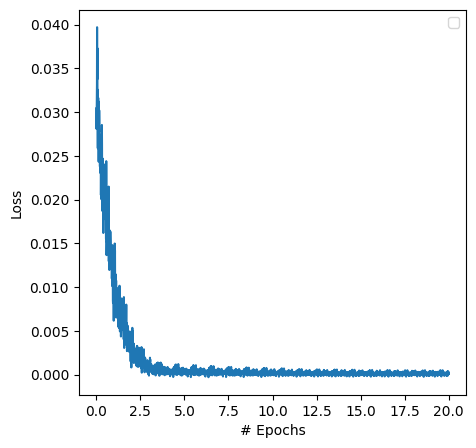

In [ ]:
PRINT_ITERS = 5
IS_LIQUID = False
for i in range(NUM_EPOCHS):

    for ibatch, (batch_pos, batch_ene, batch_scale) in enumerate(dataloader_train):
        key = next(chain)
        chain = key_chain(key)

        loss_train, flow, opt_state = make_step(
            batch_pos=batch_pos,
            batch_ene=batch_ene,
            batch_scale=batch_scale,
            flow=flow,
            temps_and_pressures=conditioning_states,
            optimized_state=opt_state,
            optim=optim,
            target_energy_fn=compute_sw_energy,
            prior_pressure=PRIOR_PRESSURE,
            reference_box=BOX_EDGES,
            prior_temp=TEMP_PRIOR,
            key=next(chain),
        )

        loss_eval = batch_loss_temp_press_vmap(
            batch_pos=batch_pos,
            batch_scale=batch_scale,
            batch_ene=batch_ene,
            temps_and_pressures=eval_state,
            flow=flow,
            prior_pressure=PRIOR_PRESSURE,
            reference_box=BOX_EDGES,
            prior_temp=TEMP_PRIOR,
            target_energy_fn=compute_sw_energy,
        )

        loss_batch_eval = loss_batch_eval.at[ibatch].set(loss_eval)

    losses_eval = jnp.concatenate((losses_eval, loss_batch_eval))
    clear_output(wait=True)
    plt.figure(figsize=(5, 5))
    plt.plot(
        np.linspace(0, losses_eval.shape[0] / n_batches, losses_eval.shape[0]),
        losses_eval / NUM_PARTICLES,
    )

    #plt.axhline(delta_f_ref, linestyle="--", color="black", label=r"MBAR $\Delta f / N$")
    plt.xlabel("# Epochs")
    plt.ylabel("Loss")
    plt.legend()
    
    # ---- Save figure ----
    plt.tight_layout()
    plt.savefig("training_loss.png", dpi=300, bbox_inches="tight")

    # ---- Close figure (important inside training loops) ----
    plt.close()

In [1]:
state_file = "training_state.pkl"
flow_file = "flow.eqx"
opt_state_file = "opt_state.eqx"

training_state = {
    "optimized_state": eqx.tree_serialise_leaves(opt_state_file, opt_state)
}

eqx.tree_serialise_leaves(flow_file, flow)

with open(state_file, "wb") as f:
    pickle.dump(training_state, f)

print(f"Training salvato con successo come {state_file}.")

NameError: name 'eqx' is not defined

In [42]:
evaluation_states = grid_conditional_variables(t_min,t_max,p_min, p_max, 8,8)


In [ ]:
n_test = 10
batch_pos = dataset_prior_test.pos[:n_test]
batch_scale = dataset_prior_test.scale[:n_test]
batch_energies = dataset_prior_test.energies[:n_test]
efficiencies = jnp.empty((0,))
deltaFs = jnp.empty((0,))

mean_disps = jnp.empty((0,n_test))

for j, state in enumerate(evaluation_states):
    logw_flow_unnormalized = jax.vmap(
            lambda pos,ene,scal: log_weights_given_latent(
                pos_prior=pos,
                prior_energy=ene,
                scale_prior=scal,
                flow=flow,
                temp_and_pressure_target=state,
                temp_and_pressure_flow=state,
                n_particles=NUM_PARTICLES,
                pressure_prior=PRIOR_PRESSURE,
                temp_prior=TEMP_PRIOR,
                reference_box=BOX_EDGES,
                target_energy_fn=compute_sw_energy,
            )
        )(batch_pos, batch_energies, batch_scale)

    logw_normalized = normalize_weights(logw_flow_unnormalized)

    deltaF = delta_f_to_prior(logw_flow_unnormalized)

    efficiency = sampling_efficiency(logw_flow_unnormalized)
    ess_flow = effective_sample_size(logw_flow_unnormalized)
    efficiencies = jnp.concatenate((efficiencies, jnp.array([ efficiency])))
    deltaFs = jnp.concatenate((deltaFs, jnp.array([ deltaF])))
    print(j, state, efficiency)

0 [2.2000000e+02 5.4916125e-02] 0.3975649
1 [2.2000000e+02 5.6659494e-02] 0.39545938
2 [2.2000000e+02 5.8402866e-02] 0.39271733
3 [2.200000e+02 6.014623e-02] 0.3893759
4 [2.20000e+02 6.18896e-02] 0.38681763
5 [2.200000e+02 6.363297e-02] 0.38561544
6 [2.200000e+02 6.537634e-02] 0.38434657
7 [2.200000e+02 6.711971e-02] 0.37977606
8 [2.3857144e+02 5.4916125e-02] 0.5929306
9 [2.3857144e+02 5.6659494e-02] 0.58901703
10 [2.3857144e+02 5.8402866e-02] 0.58400536
11 [2.3857144e+02 6.0146231e-02] 0.57797706
12 [2.3857144e+02 6.1889600e-02] 0.5725524
13 [2.3857144e+02 6.3632973e-02] 0.56809676
14 [2.3857144e+02 6.5376341e-02] 0.5602459
15 [2.3857144e+02 6.7119710e-02] 0.55353296
16 [2.5714288e+02 5.4916125e-02] 0.8806847
17 [2.5714288e+02 5.6659494e-02] 0.8829721
18 [2.5714288e+02 5.8402866e-02] 0.88292503
19 [2.5714288e+02 6.0146231e-02] 0.8803622
20 [2.5714288e+02 6.1889600e-02] 0.8769434
21 [2.5714288e+02 6.3632973e-02] 0.87277174
22 [2.5714288e+02 6.5376341e-02] 0.86582124
23 [2.5714288e+02 6

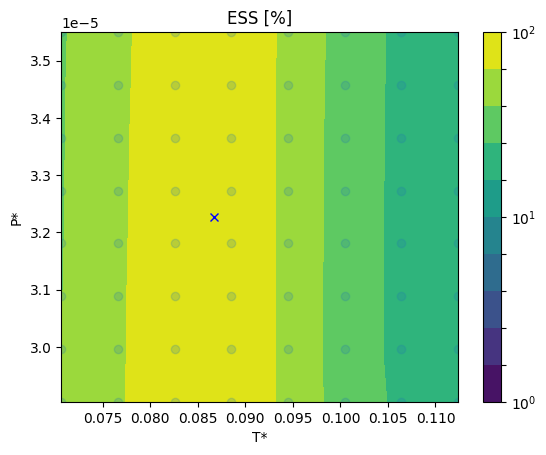

In [ ]:
contour = plt.tricontourf(
    evaluation_states[:, 0]/ convert_from_reduced_t(EPSILON, KB),
    evaluation_states[:, 1] / convert_from_reduced_p(EPSILON, SIGMA),
    efficiencies * 100,
    norm=colors.LogNorm(),
    levels=np.geomspace(1e-0, 100, 11),
)
plt.colorbar(contour, ticks=np.geomspace(1e-0, 100, 11))
plt.scatter(
    evaluation_states[:, 0] / convert_from_reduced_t(EPSILON, KB),
    evaluation_states[:, 1] / convert_from_reduced_p(EPSILON, SIGMA),
    alpha=0.2,
)
plt.plot(REDUCED_TEMP_PRIOR, REDUCED_PRESS_PRIOR, "x", color="blue")
#plt.plot(TEMP_PRIOR, PRIOR_PRESSURE, "x", color="blue")
# plt.yscale('log')
plt.set_cmap("Reds")
plt.xlabel("T*")
plt.title("ESS [%]")
plt.ylabel("P*")
#plt.axis([0.3,0.4,1.8,2.5])
plt.tight_layout()

# ---- Save figure ----
plt.savefig("ess_contour.png", dpi=300, bbox_inches="tight")

# ---- Close to free memory ----
plt.close()

In [45]:
kB = KB
def log_weights_and_conf_given_latent(
    pos_prior,
    scale_prior,
    prior_energy,
    temp_and_pressure_target,
    temp_and_pressure_flow,
    reference_box,
    n_particles,
    pressure_prior,
    temp_prior,
    target_energy_fn,
    flow,
):
    """Computes the weights for one sample.

    params:
    --------------------------
    logw: unnormalized weights"""

    prior_vol = jnp.prod(scale_prior * reference_box)

    target_temp = temp_and_pressure_target[0]
    target_press = temp_and_pressure_target[1]

    flow_temp = temp_and_pressure_flow[0]
    flow_press = temp_and_pressure_flow[1]

    new_pos, new_scale, ldj = flow.forward(
        pos=pos_prior, scale=scale_prior, temp=flow_temp, press=flow_press
    )
    new_box = new_scale * reference_box
    new_vol = jnp.prod(new_box)

    target_energy = target_energy_fn(new_pos, new_scale)

    ldj_initial = n_particles * (jnp.log(1.0 / prior_vol))
    ldj_final = n_particles * (jnp.log(new_vol))

    ldj += ldj_final + ldj_initial
    logw = (
        -(target_energy + new_vol * target_press) / (kB * target_temp)
        + ldj
        + (prior_energy + prior_vol * pressure_prior) / (kB * temp_prior)
    )

    return logw, new_pos, new_scale, target_energy


In [46]:
n_test = len(dataset_prior_test.energies)


In [47]:
test_temp_list = jnp.array([230., 240., 250., 260., 270., 280., 290., 300., 310., 320., 330., 340.])


batch_pos = dataset_prior_test.pos[:n_test]
batch_scale = dataset_prior_test.scale[:n_test]
batch_energies = dataset_prior_test.energies[:n_test]

chunk_size = 128 
# 120 - > 64
# 60 particles - > 128

n_samples = batch_pos.shape[0]

In [48]:
weight_array = jnp.zeros((len(test_temp_list), n_test))
position_array = jnp.zeros((len(test_temp_list), n_test, NUM_PARTICLES, SPATIAL_DIMENSIONS))
scale_array = jnp.zeros((len(test_temp_list), n_test))
energy_array = jnp.zeros((len(test_temp_list), n_test))

for i in range(len(test_temp_list)):
    test_temp = test_temp_list[i]

    n_samples = batch_pos.shape[0]

    # Prepare accumulators for this temperature
    w_norm = jnp.zeros(n_test)
    pos = jnp.zeros((n_test, NUM_PARTICLES, SPATIAL_DIMENSIONS))
    scale = jnp.zeros(n_test)
    energy = jnp.zeros(n_test)

    for start in range(0, n_samples, chunk_size):
        end = min(start + chunk_size, n_samples)
        pos_chunk = batch_pos[start:end]
        ene_chunk = batch_energies[start:end]
        scale_chunk = batch_scale[start:end]

        w_x_L_E_chunk = jax.vmap(lambda pos, ene, scal: log_weights_and_conf_given_latent(
            pos_prior=pos,
            prior_energy=ene,
            scale_prior=scal,
            flow=flow,
            temp_and_pressure_target=jnp.array([test_temp, PRIOR_PRESSURE]),
            temp_and_pressure_flow=jnp.array([test_temp, PRIOR_PRESSURE]),
            n_particles=NUM_PARTICLES,
            pressure_prior=PRIOR_PRESSURE,
            temp_prior=TEMP_PRIOR,
            reference_box=BOX_EDGES,
            target_energy_fn=compute_sw_energy,
        ))(pos_chunk, ene_chunk, scale_chunk)

        w_norm_chunk = normalize_weights(w_x_L_E_chunk[0])


        w_norm = w_norm.at[start:end].set(w_norm_chunk)
        pos = pos.at[start:end].set(w_x_L_E_chunk[1])
        scale = scale.at[start:end].set(w_x_L_E_chunk[2])
        energy = energy.at[start:end].set(w_x_L_E_chunk[3])
    


    print("Calculated for temp = ", test_temp)


    print("E[Energy] = ", energy)
    print("E[Scale] = ", scale)


    weight_array = weight_array.at[i].set(w_norm)
    position_array = position_array.at[i].set(pos)
    scale_array = scale_array.at[i].set(scale)
    energy_array = energy_array.at[i].set(energy)



Calculated for temp =  230.0
E[Energy] =  [-2580.116  -2568.6416 -2619.317  ... -2576.193  -2569.1677 -2528.2368]
E[Scale] =  [0.9945566  0.99648434 0.99103194 ... 0.99166644 1.0059048  0.99528825]
Calculated for temp =  240.0
E[Energy] =  [-2580.0623 -2568.5125 -2619.3433 ... -2576.3293 -2569.2175 -2528.4346]
E[Scale] =  [0.9945566  0.99648434 0.99103194 ... 0.99166644 1.0059048  0.99528825]
Calculated for temp =  250.0
E[Energy] =  [-2579.954  -2568.39   -2619.3362 ... -2576.352  -2569.3137 -2528.5955]
E[Scale] =  [0.9945566  0.99648434 0.99103194 ... 0.99166644 1.0059048  0.99528825]
Calculated for temp =  260.0
E[Energy] =  [-2579.7947 -2568.296  -2619.2864 ... -2576.2908 -2569.375  -2528.6492]
E[Scale] =  [0.9945566  0.99648434 0.99103194 ... 0.99166644 1.0059049  0.99528825]
Calculated for temp =  270.0
E[Energy] =  [-2579.7205 -2568.2742 -2619.2808 ... -2576.2283 -2569.3438 -2528.6543]
E[Scale] =  [0.9945566  0.99648434 0.99103194 ... 0.99166644 1.0059049  0.99528825]
Calculated

In [49]:
def weighted_var(list, avg, log_weights):
    return jnp.sum(jnp.exp(log_weights)*((list - avg)**2))/jnp.sum(jnp.exp(log_weights))

import mdtraj as md
def radial_distribution_function_single(
    pos, box, num_particles, n_bins=200, n_dims=3, r_range=None, **kwargs
):
    """Compute the RDF of the data, using mdtraj"""

    top = md.Topology()
    res = top.add_residue('LJ', top.add_chain())
    for i in range(num_particles): #element type does not matter
        top.add_atom('Ar', md.element.Element.getBySymbol('Ar'), res)

    # assert jnp.abs(data.max()) <= 1 and data.min() >= 0, "data should be rescaled"
    assert pos.shape[-1] == 3 and pos.shape[-2] == num_particles

    box_mean = box
    #assert box_mean.shape == (3,)

    if r_range is None:
        r_range = (0, np.sqrt(np.sum(np.power(box_mean, 2))) / 2)
        # r_range = (0, 1)

    # box is needed for PBC. assumed to be cubic/squared
    unitcell = {
        "unitcell_lengths": box,
        "unitcell_angles": np.full((1, n_dims), 90),
    }
    # create mdtraj traj object
    traj = md.Trajectory(pos, top, **unitcell)
    ij = np.array(np.triu_indices(num_particles, k=1)).T
    rdf = md.compute_rdf(traj, ij, r_range=r_range, n_bins=n_bins)

    return rdf
def radial_distribution_function_weighted( w_norm, reduced_positions, red_volumes, n_particles):

    wheights = w_norm
    pos = reduced_positions
    box = np.zeros((len(pos), 3))
    box[:,0] = red_volumes   #box = scale * BOX_EDGES
    box[:,1] = red_volumes
    box[:,2] = red_volumes
        #box = jnp.array(w_x_L_E_dict[(test_temp_list[i], PRIOR_PRESSURE)]["scales"]) #box = scale * BOX_EDGES
    rdf = radial_distribution_function_single(pos[0], box[0], n_particles)
    rdf_bins_j = np.array(rdf[0]) * jnp.exp(wheights[0]) 
    rdf_j = np.array(rdf[1]) * jnp.exp(wheights[0]) #in units nm
    for j in range(1, len(pos)):
        pos_j = pos[j]
        box_j = box[j]
        rdf = radial_distribution_function_single(pos_j, box_j, n_particles)
        rdf_bins_j += np.array(rdf[0]) * jnp.exp(wheights[j]) #in units nm
        rdf_j += np.array(rdf[1]) * jnp.exp(wheights[j]) #in units nm

    normalization = jnp.sum(jnp.exp(wheights))

    return rdf_bins_j/normalization, rdf_j/normalization
        #print("Calculated RDF for temperature: ", test_temp_list[i])


        #rdf = radial_distribution_function_single(pos[0], box[0], NUM_PARTICLES) #r_max = 5.0 nm

        #plt.plot(*rdf)
        #plt.title(f"RDF at {test_temp_list[i]} K")
        #plt.xlabel('r (nm)')
        #plt.ylabel('g(r)')
        #plt.show()
        #plot realtime in same figure like in the training loop
        

In [ ]:
vc_md = np.load("MD_VC_DATA_"+str(NUM_PARTICLES)+".npz")["v_c_list"]
K_md = np.load("MD_K_DATA_"+str(NUM_PARTICLES)+".npz")["K_list"]

v_c_list = np.zeros(len(test_temp_list))
K_list = np.zeros(len(test_temp_list))
ess_list = np.zeros(len(test_temp_list))
for k in range(len(test_temp_list)):
    w_norm = weight_array[k]
    scales = scale_array[k]
    v_red = (scales * BOX_EDGES[0]/SIGMA)**3
    v_red_avg = np.sum(jnp.exp(w_norm)*v_red)/jnp.sum(jnp.exp(w_norm))
    v_red_var = weighted_var(v_red, v_red_avg, w_norm)
    #print(v_red_var)
    v_c = v_red / NUM_PARTICLES
    v_c_list[k] = np.sum(jnp.exp(w_norm)*v_c)/jnp.sum(jnp.exp(w_norm))
    K_list[k] = (v_red_var/v_red_avg)/(test_temp_list[k]*conv_t)
    ess_list[k] = effective_sample_size(w_norm)/ len(w_norm)





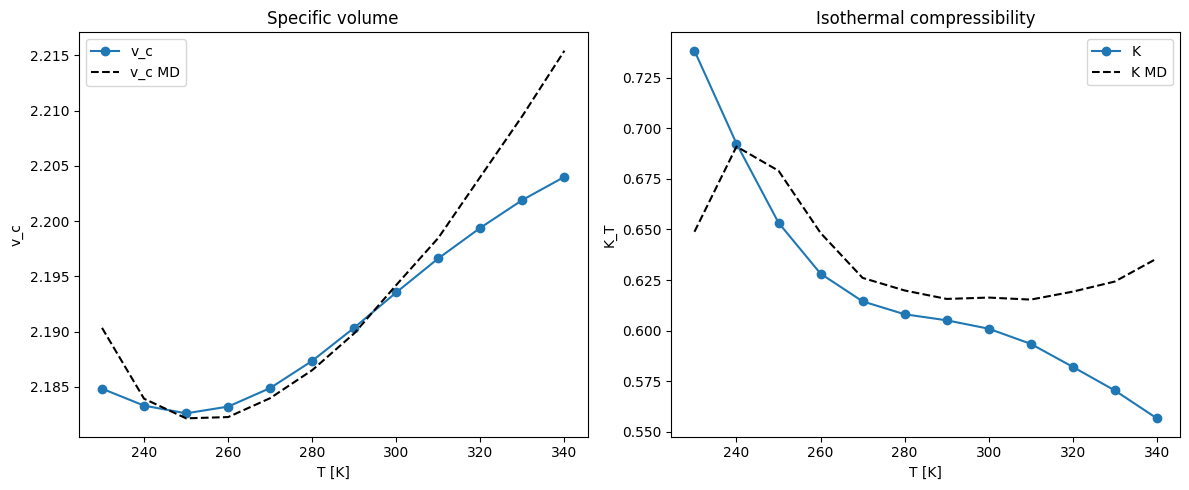

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(test_temp_list, v_c_list, label='v_c', linestyle='-', marker='o')
ax[0].plot(test_temp_list, vc_md, label='v_c MD', color='black', linestyle='--')
ax[0].set_xlabel('T [K]')
ax[0].set_ylabel('v_c')
ax[0].legend()
ax[0].set_title('Specific volume')

ax[1].plot(test_temp_list, K_list, label='K', marker='o')
ax[1].plot(test_temp_list, K_md, label='K MD', color='black', linestyle='--')
ax[1].set_xlabel('T [K]')
ax[1].set_ylabel('K_T')
ax[1].legend()
ax[1].set_title('Isothermal compressibility')


plt.tight_layout()

# Save the figure
plt.savefig("thermo_properties.png", dpi=300, bbox_inches='tight')


# ---- Save curve data ----
data = pd.DataFrame({
    "T [K]": test_temp_list,
    "v_c": v_c_list,
    "v_c MD": vc_md,
    "K": K_list,
    "K MD": K_md
})

data.to_csv("thermo_properties_data.csv", index=False)

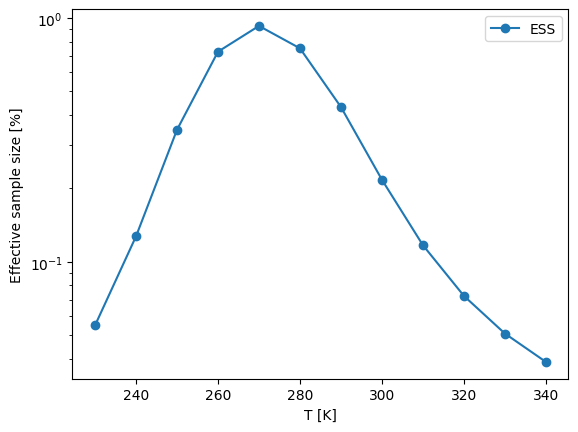

In [ ]:
plt.plot(test_temp_list, ess_list, label='ESS', marker='o')
plt.xlabel('T [K]')
plt.yscale('log')
plt.ylabel('Effective sample size [%]')
plt.tight_layout()

# ---- Save figure ----
plt.savefig("eff_vs_T.png", dpi=300, bbox_inches="tight")

# ---- Close to free memory ----
plt.close()